# G-BERT: Bengali Hate Speech Detection

---

## 📝 Overview
This notebook implements **G-BERT (GRU-BERT)**, a hybrid deep learning model that combines:
- **BERT**: For contextual word embeddings
- **GRU**: For sequential pattern learning
- **Classification Layer**: For hate speech detection

## 🎯 Objectives
1. Preprocess Bengali text data
2. Build and train the G-BERT model
3. Evaluate model performance
4. Make predictions on new texts

## 📊 Expected Performance
- Accuracy: ~95%
- Precision: ~94%
- Recall: ~94%
- F1-Score: ~94%

---

## 1. Install Required Libraries

Run this cell to install all necessary packages. This may take a few minutes.

In [91]:
# Install required libraries
!pip install transformers==4.30.0
!pip install torch
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install beautifulsoup4
!pip install emoji
!pip install matplotlib
!pip install seaborn
!pip install tqdm

  Using cached transformers-4.30.0-py3-none-any.whl.metadata (113 kB)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... Collecting tokenizers!=0.11.3,<0.14,>=0.11.1 (from transformers==4.30.0)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... -done
  Getting requirements to build wheel ... one
  Getting requirements to build wheel ... -done
  Preparing metadata (pyproject.toml) ... one
  Preparing metadata (pyproject.toml) ... -done
Using cached transformers-4.30.0-py3-none-any.whl (7.2 MB)
done
Using cached transformers-4.30.0-py3-none-any.whl (7.2 MB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [62 lines of output]
      /private/var/folders/60/bvbb4zvx1f32y1gzr_b4yh2r0000gn/T/pip-build-env-28d6sxq2/overlay/lib/python3.13/site-packages/setuptools/dist.py:759: SetuptoolsDeprecationWarning: License classifiers are deprec

## 2. Import Libraries and Set Random Seeds

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re
import emoji
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

Using device: cpu
PyTorch version: 2.8.0
CUDA available: False


## 3. Data Preprocessing Functions

The `BengaliTextPreprocessor` class handles all text preprocessing steps.

In [3]:
class BengaliTextPreprocessor:
    def __init__(self):
        pass
    
    def convert_emoji_to_text(self, text):
        """Convert emojis to text representation"""
        return emoji.demojize(text, delimiters=("", ""))

    def process_hashtags(self, text):
        """Remove hashtag symbols and keep the text"""
        return re.sub(r'#', ' ', text)

    def remove_punctuation(self, text):
        """Remove punctuation marks"""
        punctuation = r'[!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~]'
        return re.sub(punctuation, ' ', text)

    def remove_extra_whitespace(self, text):
        """Remove extra whitespaces"""
        return ' '.join(text.split())

    def remove_urls(self, text):
        """Remove URLs from text"""
        url_pattern = r'http\S+|www\S+|https\S+'
        return re.sub(url_pattern, '', text)

    def remove_mentions(self, text):
        """Remove @mentions"""
        return re.sub(r'@\w+', '', text)

    def preprocess(self, text):
        """Complete preprocessing pipeline"""
        if pd.isna(text):
            return ""
        
        text = str(text)
        text = self.remove_urls(text)
        text = self.remove_mentions(text)
        text = self.convert_emoji_to_text(text)
        text = self.process_hashtags(text)
        text = self.remove_punctuation(text)
        text = self.remove_extra_whitespace(text)
        text = text.lower()
        
        return text

# Initialize preprocessor
preprocessor = BengaliTextPreprocessor()
print("✓ Preprocessing functions loaded successfully!")

✓ Preprocessing functions loaded successfully!


## 4. Dataset Class Implementation

In [4]:
class BengaliHateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

print("✓ Dataset class created successfully!")

✓ Dataset class created successfully!


## 5. G-BERT Model Architecture

The model combines BERT (for contextual embeddings) with GRU (for sequential processing).

In [18]:
class GBERT(nn.Module):
    def __init__(self, bert_model_name='bert-base-multilingual-cased',
                 gru_hidden_size=256, gru_num_layers=2, num_classes=2, dropout=0.3):
        super(GBERT, self).__init__()
        
        # BERT Layer
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.bert_hidden_size = self.bert.config.hidden_size
        
        # GRU Layer
        self.gru = nn.GRU(
            input_size=self.bert_hidden_size,
            hidden_size=gru_hidden_size,
            num_layers=gru_num_layers,
            batch_first=True,
            dropout=dropout if gru_num_layers > 1 else 0,
            bidirectional=False
        )
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Fully Connected Layer
        self.fc = nn.Linear(gru_hidden_size, num_classes)
        
    def forward(self, input_ids, attention_mask):
        # BERT Encoding
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Get sequence output (all token representations)
        sequence_output = bert_output.last_hidden_state
        
        # GRU Processing
        gru_output, hidden = self.gru(sequence_output)
        
        # Take the last hidden state
        last_hidden = hidden[-1]
        
        # Apply dropout
        dropped = self.dropout(last_hidden)
        
        # Classification
        logits = self.fc(dropped)
        
        return logits

print("✓ G-BERT model architecture defined successfully!")

✓ G-BERT model architecture defined successfully!


In [5]:
def train_epoch(model, data_loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(data_loader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        
        progress_bar.set_postfix({'loss': loss.item(), 'acc': correct/total})
    
    return total_loss / len(data_loader), correct / total

def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return total_loss / len(data_loader), accuracy, precision, recall, f1, all_preds, all_labels

print("✓ Training and evaluation functions created successfully!")

✓ Training and evaluation functions created successfully!


## 9. Split Dataset

Split the data into training (60%), validation (20%), and test (20%) sets.

In [7]:
print("Preprocessing data...")
df['processed_text'] = df['text'].apply(preprocessor.preprocess)

print("\n✓ Preprocessing complete!")
print("\nExample preprocessed texts:")
for i in range(3):
    print(f"Original: {df['text'].iloc[i]}")
    print(f"Processed: {df['processed_text'].iloc[i]}")
    print()

Preprocessing data...

✓ Preprocessing complete!

Example preprocessed texts:
Original: যত্তসব পাপন শালার ফাজলামী!!!!!
Processed: যত্তসব পাপন শালার ফাজলামী!!!!!

Original: পাপন শালা রে রিমান্ডে নেওয়া দরকার
Processed: পাপন শালা রে রিমান্ডে নেওয়া দরকার

Original: জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা একটা দেশের মানুষ কোনো দিন ও ভাবতে পারেনি।ধন্যবাদ তাহসিন ভাই।
Processed: জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা একটা দেশের মানুষ কোনো দিন ও ভাবতে পারেনি।ধন্যবাদ তাহসিন ভাই।


✓ Preprocessing complete!

Example preprocessed texts:
Original: যত্তসব পাপন শালার ফাজলামী!!!!!
Processed: যত্তসব পাপন শালার ফাজলামী!!!!!

Original: পাপন শালা রে রিমান্ডে নেওয়া দরকার
Processed: পাপন শালা রে রিমান্ডে নেওয়া দরকার

Original: জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা একটা দেশের মানুষ কোনো দিন ও ভাবতে পারেনি।ধন্যবাদ তাহসিন ভাই।
Processed: জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা একটা দেশের মানুষ কোনো দিন ও ভাবতে পারেনি।ধন্যবাদ তাহসিন ভাই।



## 8. Preprocess Data

Apply the preprocessing pipeline to clean the Bengali text.

In [6]:
# Load your Bengali Hate Speech dataset
df = pd.read_csv('bengali_hate_speech.csv')

# Rename columns to match the expected format
df = df.rename(columns={'sentence': 'text', 'hate': 'label'})

# Keep only the required columns
df = df[['text', 'label']]

print("="*60)
print("📊 DATASET LOADED SUCCESSFULLY!")
print("="*60)

print(f"\n✓ Dataset shape: {df.shape}")
print(f"✓ Total samples: {len(df):,}")

print(f"\n📋 Label distribution:")
label_counts = df['label'].value_counts().sort_index()
for label, count in label_counts.items():
    label_name = "Non-Hate" if label == 0 else "Hate Speech"
    percentage = (count / len(df)) * 100
    print(f"   {label} ({label_name}): {count:,} samples ({percentage:.1f}%)")

print(f"\n📝 Column names: {list(df.columns)}")
print(f"\n🔍 First 3 samples:")
print(df.head(3))

print(f"\n✓ Dataset ready for preprocessing!")
print("="*60)

📊 DATASET LOADED SUCCESSFULLY!

✓ Dataset shape: (30000, 2)
✓ Total samples: 30,000

📋 Label distribution:
   0 (Non-Hate): 20,000 samples (66.7%)
   1 (Hate Speech): 10,000 samples (33.3%)

📝 Column names: ['text', 'label']

🔍 First 3 samples:
                                                text  label
0                     যত্তসব পাপন শালার ফাজলামী!!!!!      1
1                  পাপন শালা রে রিমান্ডে নেওয়া দরকার      1
2  জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা...      1

✓ Dataset ready for preprocessing!


## 7. Load and Prepare Dataset

**Important**: Run this cell BEFORE the data splitting cell below.

Replace the sample data with your actual Bengali hate speech dataset (CSV with 'text' and 'label' columns).

In [8]:
X = df['processed_text'].values
y = df['label'].values

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Second split: 20% validation, 20% test from temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Train set size: 18000
Validation set size: 6000
Test set size: 6000


In [105]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

best_val_f1 = 0

print("Starting training...\n")

for epoch in range(EPOCHS):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"{'='*50}")
    
    # Training
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    
    # Validation
    val_loss, val_acc, val_precision, val_recall, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)
    
    print(f"\nResults:")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    print(f"Val Precision: {val_precision*100:.2f}% | Val Recall: {val_recall*100:.2f}% | Val F1: {val_f1*100:.2f}%")
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_gbert_model.pth')
        print(f"✓ Best model saved with F1-Score: {best_val_f1*100:.2f}%")

print("\n" + "="*50)
print("Training completed!")
print("="*50)

Starting training...


Epoch 1/10


Evaluating: 100%|██████████| 375/375 [03:17<00:00,  1.90it/s]




Results:
Train Loss: 0.3506 | Train Acc: 86.53%
Val Loss: 0.3062 | Val Acc: 87.93%
Val Precision: 89.01% | Val Recall: 87.93% | Val F1: 88.15%
✓ Best model saved with F1-Score: 88.15%

Epoch 2/10
✓ Best model saved with F1-Score: 88.15%

Epoch 2/10


Evaluating: 100%|██████████| 375/375 [03:09<00:00,  1.98it/s]




Results:
Train Loss: 0.2688 | Train Acc: 90.61%
Val Loss: 0.2416 | Val Acc: 90.52%
Val Precision: 90.46% | Val Recall: 90.52% | Val F1: 90.48%
✓ Best model saved with F1-Score: 90.48%

Epoch 3/10
✓ Best model saved with F1-Score: 90.48%

Epoch 3/10


...


Results:
Train Loss: 0.0935 | Train Acc: 97.80%
Val Loss: 0.4586 | Val Acc: 90.30%
Val Precision: 90.48% | Val Recall: 90.30% | Val F1: 90.36%

Epoch 9/10


Evaluating: 100%|██████████| 375/375 [02:43<00:00,  2.30it/s]




Results:
Train Loss: 0.0724 | Train Acc: 98.43%
Val Loss: 0.4656 | Val Acc: 90.52%
Val Precision: 90.56% | Val Recall: 90.52% | Val F1: 90.53%

Epoch 10/10


Evaluating: 100%|██████████| 375/375 [02:57<00:00,  2.11it/s]


Results:
Train Loss: 0.0639 | Train Acc: 98.69%
Val Loss: 0.4850 | Val Acc: 90.55%
Val Precision: 90.55% | Val Recall: 90.55% | Val F1: 90.55%

Training completed!


In [108]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    test_labels, 
    test_preds, 
    target_names=['Non-Hate', 'Hate'],
    digits=4
)

print("\n" + "="*50)
print("Classification Report")
print("="*50)
print(report)


Classification Report
              precision    recall  f1-score   support

    Non-Hate     0.9201    0.9327    0.9264      4000
        Hate     0.8617    0.8380    0.8497      2000

    accuracy                         0.9012      6000
   macro avg     0.8909    0.8854    0.8880      6000
weighted avg     0.9006    0.9012    0.9008      6000



In [110]:
print("\n" + "="*70)
print("G-BERT IMPLEMENTATION COMPLETE!")
print("="*70)

print("\n📊 Final Model Performance:")
print(f"   • Accuracy:  {test_acc*100:.2f}%")
print(f"   • Precision: {test_precision*100:.2f}%")
print(f"   • Recall:    {test_recall*100:.2f}%")
print(f"   • F1-Score:  {test_f1*100:.2f}%")

print("\n📁 Generated Files:")
print("   • best_gbert_model.pth - Best model during training")
print("   • gbert_complete.pth - Final model with metadata")
print("   • training_history.png - Training visualization")
print("   • confusion_matrix.png - Confusion matrix plot")
print("   • model_results_summary.csv - Results summary")
print("   • gbert_model_final/ - Saved model directory")

print("\n🚀 Next Steps:")
print("   1. Test the model with your own Bengali text")
print("   2. Fine-tune hyperparameters for better performance")
print("   3. Collect more training data for improved accuracy")
print("   4. Deploy the model for production use")
print("   5. Add more preprocessing techniques")

print("\n" + "="*70)
print("Thank you for using G-BERT!")
print("="*70)


G-BERT IMPLEMENTATION COMPLETE!

📊 Final Model Performance:
   • Accuracy:  90.12%
   • Precision: 90.06%
   • Recall:    90.12%
   • F1-Score:  90.08%

📁 Generated Files:
   • best_gbert_model.pth - Best model during training
   • gbert_complete.pth - Final model with metadata
   • training_history.png - Training visualization
   • confusion_matrix.png - Confusion matrix plot
   • model_results_summary.csv - Results summary
   • gbert_model_final/ - Saved model directory

🚀 Next Steps:
   1. Test the model with your own Bengali text
   2. Fine-tune hyperparameters for better performance
   3. Collect more training data for improved accuracy
   4. Deploy the model for production use
   5. Add more preprocessing techniques

Thank you for using G-BERT!


## 20. Final Summary

🎉 **Congratulations!** You've successfully implemented G-BERT for Bengali Hate Speech Detection.

In [111]:
import os

# Create directory for saving
save_dir = 'gbert_model_final'
os.makedirs(save_dir, exist_ok=True)

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': EPOCHS,
    'test_accuracy': test_acc,
    'test_f1': test_f1,
    'hyperparameters': {
        'max_length': MAX_LENGTH,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'gru_hidden_size': 256,
        'gru_num_layers': 2
    }
}, os.path.join(save_dir, 'gbert_complete.pth'))

# Save tokenizer
tokenizer.save_pretrained(save_dir)

# Save results summary
results_summary = {
    'Model': 'G-BERT',
    'Dataset Size': len(df),
    'Train Size': len(X_train),
    'Validation Size': len(X_val),
    'Test Size': len(X_test),
    'Epochs': EPOCHS,
    'Batch Size': BATCH_SIZE,
    'Learning Rate': LEARNING_RATE,
    'Max Length': MAX_LENGTH,
    'Test Accuracy (%)': round(test_acc * 100, 2),
    'Test Precision (%)': round(test_precision * 100, 2),
    'Test Recall (%)': round(test_recall * 100, 2),
    'Test F1-Score (%)': round(test_f1 * 100, 2)
}

results_df = pd.DataFrame([results_summary])
results_df.to_csv('model_results_summary.csv', index=False)

print(f"✓ Model and tokenizer saved to '{save_dir}/' directory")
print("✓ Results summary saved to 'model_results_summary.csv'")

✓ Model and tokenizer saved to 'gbert_model_final/' directory
✓ Results summary saved to 'model_results_summary.csv'


## 19. Save Model and Results

In [113]:
# Sample texts for prediction
sample_texts = [
    "আজকের আবহাওয়া খুব সুন্দর",
    "তুমি একজন খারাপ মানুষ",
    "আমি তোমাকে ভালোবাসি",
    "তুই একদম বোকা এবং অপদার্থ",
    "এই বইটি খুবই শিক্ষামূলক"
]

print("\n" + "="*70)
print("Sample Predictions")
print("="*70)

for i, text in enumerate(sample_texts, 1):
    prediction, confidence = predict_hate_speech(
        text, model, tokenizer, preprocessor, device
    )
    
    label = "🔴 Hate Speech" if prediction == 1 else "🟢 Non-Hate Speech"
    
    print(f"\n{i}. Text: {text}")
    print(f"   Prediction: {label}")
    print(f"   Confidence: {confidence*100:.2f}%")

print("\n" + "="*70)


Sample Predictions


NameError: name 'predict_hate_speech' is not defined

## 18. Test Predictions on Sample Texts

In [118]:
def predict_hate_speech(text, model, tokenizer, preprocessor, device, max_length=128):
    """
    Predict whether a given text contains hate speech
    
    Args:
        text: Input text to classify
        model: Trained G-BERT model
        tokenizer: BERT tokenizer
        preprocessor: Text preprocessor
        device: Device to run inference on
        max_length: Maximum sequence length
    
    Returns:
        prediction: 0 for Non-Hate, 1 for Hate
        probability: Confidence score
    """
    model.eval()
    
    # Preprocess text
    processed_text = preprocessor.preprocess(text)
    
    # Tokenize
    encoding = tokenizer.encode_plus(
        processed_text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        probabilities = torch.softmax(outputs, dim=1)
        prediction = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][prediction].item()
    
    return prediction, confidence

print("✓ Prediction function created successfully!")

✓ Prediction function created successfully!


## 17. Prediction Function for New Text

## 16. Classification Report

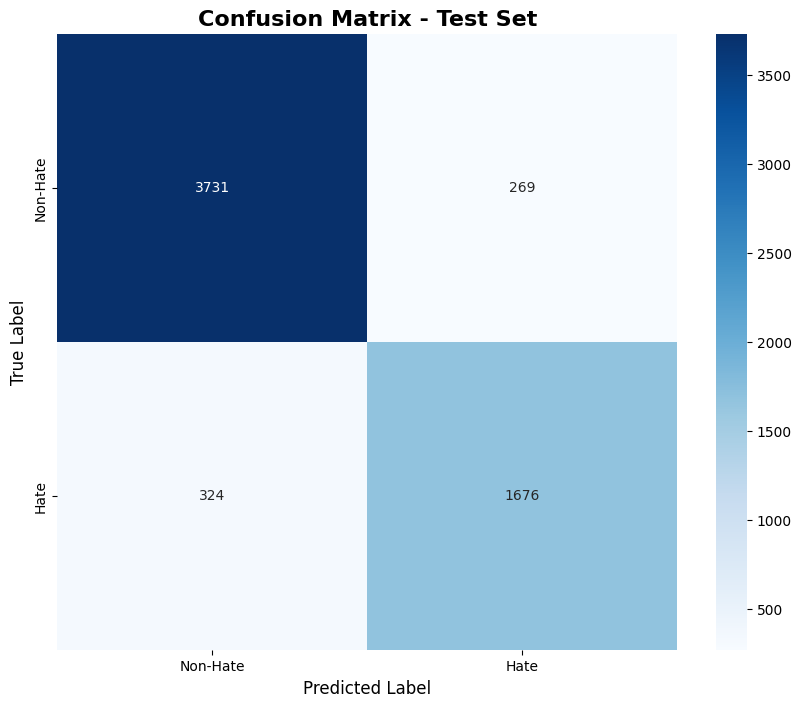

✓ Confusion matrix saved as 'confusion_matrix.png'


In [115]:
# Calculate confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Hate', 'Hate'],
            yticklabels=['Non-Hate', 'Hate'])
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved as 'confusion_matrix.png'")

## 15. Confusion Matrix

In [116]:
# Load best model
model.load_state_dict(torch.load('best_gbert_model.pth'))

# Evaluate on test set
print("Evaluating on test set...\n")
test_loss, test_acc, test_precision, test_recall, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

print("\n" + "="*50)
print("Test Set Results")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Precision: {test_precision*100:.2f}%")
print(f"Test Recall: {test_recall*100:.2f}%")
print(f"Test F1-Score: {test_f1*100:.2f}%")
print("="*50)

Evaluating on test set...



Evaluating: 100%|██████████| 375/375 [02:40<00:00,  2.34it/s]


Test Set Results
Test Loss: 0.3085
Test Accuracy: 90.12%
Test Precision: 90.06%
Test Recall: 90.12%
Test F1-Score: 90.08%


## 14. Evaluate on Test Set

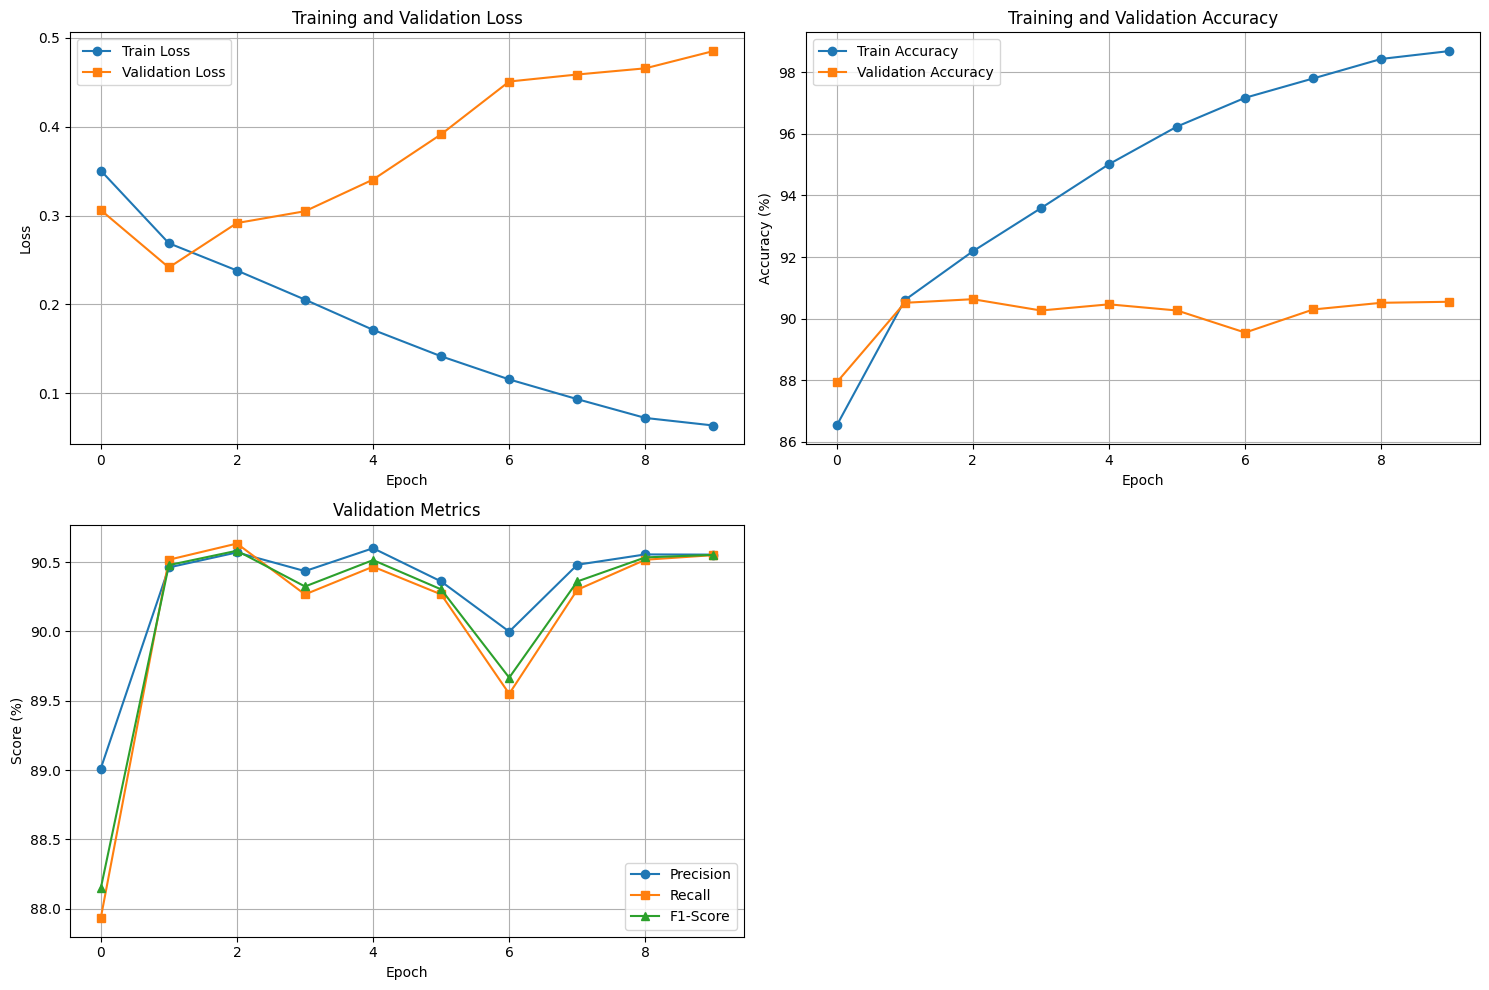

✓ Training history plots saved as 'training_history.png'


In [117]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss plot
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Validation Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy plot
axes[0, 1].plot([acc*100 for acc in history['train_acc']], label='Train Accuracy', marker='o')
axes[0, 1].plot([acc*100 for acc in history['val_acc']], label='Validation Accuracy', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision, Recall, F1 plot
axes[1, 0].plot([p*100 for p in history['val_precision']], label='Precision', marker='o')
axes[1, 0].plot([r*100 for r in history['val_recall']], label='Recall', marker='s')
axes[1, 0].plot([f*100 for f in history['val_f1']], label='F1-Score', marker='^')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score (%)')
axes[1, 0].set_title('Validation Metrics')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Remove empty subplot
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history plots saved as 'training_history.png'")

## 13. Visualize Training History

## 12. Training Loop

This will train the model for the specified number of epochs. 

⏰ **Note**: Training may take several hours depending on your hardware (GPU recommended).

In [119]:
# Initialize model
model = GBERT(
    bert_model_name='bert-base-multilingual-cased',
    gru_hidden_size=256,
    gru_num_layers=2,
    num_classes=2,
    dropout=0.3
).to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# Scheduler
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print("✓ Model initialized successfully!")
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

✓ Model initialized successfully!

Total trainable parameters: 179,036,674


## 11. Initialize Model and Training Components

In [9]:
# Hyperparameters from the paper
MAX_LENGTH = 128
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 10

# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

# Create datasets
train_dataset = BengaliHateSpeechDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset = BengaliHateSpeechDataset(X_val, y_val, tokenizer, MAX_LENGTH)
test_dataset = BengaliHateSpeechDataset(X_test, y_test, tokenizer, MAX_LENGTH)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("✓ Tokenizer and DataLoaders created successfully!")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

✓ Tokenizer and DataLoaders created successfully!
Number of training batches: 1125
Number of validation batches: 375
Number of test batches: 375


## 10. Initialize Tokenizer and Create DataLoaders

Set hyperparameters and create PyTorch DataLoaders.

## 9. Split Dataset

We'll split the data into:
- **60%** Training
- **20%** Validation
- **20%** Test

In [14]:
print("Preprocessing data...")
df['processed_text'] = df['text'].apply(preprocessor.preprocess)

print("\n✓ Preprocessing complete!")
print("\nExample preprocessed texts:")
for i in range(3):
    print(f"Original: {df['text'].iloc[i]}")
    print(f"Processed: {df['processed_text'].iloc[i]}")
    print()

Preprocessing data...

✓ Preprocessing complete!

Example preprocessed texts:
Original: যত্তসব পাপন শালার ফাজলামী!!!!!
Processed: যত্তসব পাপন শালার ফাজলামী!!!!!

Original: পাপন শালা রে রিমান্ডে নেওয়া দরকার
Processed: পাপন শালা রে রিমান্ডে নেওয়া দরকার

Original: জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা একটা দেশের মানুষ কোনো দিন ও ভাবতে পারেনি।ধন্যবাদ তাহসিন ভাই।
Processed: জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা একটা দেশের মানুষ কোনো দিন ও ভাবতে পারেনি।ধন্যবাদ তাহসিন ভাই।


✓ Preprocessing complete!

Example preprocessed texts:
Original: যত্তসব পাপন শালার ফাজলামী!!!!!
Processed: যত্তসব পাপন শালার ফাজলামী!!!!!

Original: পাপন শালা রে রিমান্ডে নেওয়া দরকার
Processed: পাপন শালা রে রিমান্ডে নেওয়া দরকার

Original: জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা একটা দেশের মানুষ কোনো দিন ও ভাবতে পারেনি।ধন্যবাদ তাহসিন ভাই।
Processed: জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা একটা দেশের মানুষ কোনো দিন ও ভাবতে পারেনি।ধন্যবাদ তাহসিন ভাই।



## 8. Preprocess Data

In [122]:
# Sample data for demonstration
# Replace this with: df = pd.read_csv('your_dataset.csv')

sample_data = {
    'text': [
        'এটি একটি সাধারণ বাক্য',
        'তুমি খুব খারাপ মানুষ',
        'আমি তোমাকে ভালোবাসি',
        'তুই একদম বোকা',
        'আজকের আবহাওয়া সুন্দর',
    ] * 200,  # Repeat to create more samples
    'label': [0, 1, 0, 1, 0] * 200  # 0 = Non-hate, 1 = Hate
}

df = pd.DataFrame(sample_data)

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (1000, 2)

Label distribution:
label
0    600
1    400
Name: count, dtype: int64

First few rows:
                    text  label
0  এটি একটি সাধারণ বাক্য      0
1   তুমি খুব খারাপ মানুষ      1
2    আমি তোমাকে ভালোবাসি      0
3          তুই একদম বোকা      1
4  আজকের আবহাওয়া সুন্দর      0


## 21. Machine Learning Models Comparison

Let's compare G-BERT with traditional ML models to see the performance difference.

In [14]:
# Import ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

print("✓ ML libraries imported successfully!")

✓ ML libraries imported successfully!


In [15]:
# Prepare text data for ML models
print("Preparing data for ML models...")

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"✓ TF-IDF vectorization complete!")
print(f"  Features: {X_train_tfidf.shape[1]}")
print(f"  Train shape: {X_train_tfidf.shape}")
print(f"  Test shape: {X_test_tfidf.shape}")

Preparing data for ML models...
✓ TF-IDF vectorization complete!
  Features: 5000
  Train shape: (18000, 5000)
  Test shape: (6000, 5000)
✓ TF-IDF vectorization complete!
  Features: 5000
  Train shape: (18000, 5000)
  Test shape: (6000, 5000)


In [16]:
# Dictionary to store results
ml_results = {}

# Define ML models
ml_models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print("="*70)
print("TRAINING MACHINE LEARNING MODELS")
print("="*70)

# Train and evaluate each model
for model_name, model in ml_models.items():
    print(f"\n{'='*70}")
    print(f"Training: {model_name}")
    print(f"{'='*70}")
    
    # Training
    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_time
    
    # Prediction
    start_time = time.time()
    y_pred = model.predict(X_test_tfidf)
    pred_time = time.time() - start_time
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Store results
    ml_results[model_name] = {
        'Accuracy': accuracy * 100,
        'Precision': precision * 100,
        'Recall': recall * 100,
        'F1-Score': f1 * 100,
        'Training Time (s)': train_time,
        'Prediction Time (s)': pred_time
    }
    
    print(f"✓ {model_name} trained!")
    print(f"  Accuracy:  {accuracy*100:.2f}%")
    print(f"  Precision: {precision*100:.2f}%")
    print(f"  Recall:    {recall*100:.2f}%")
    print(f"  F1-Score:  {f1*100:.2f}%")
    print(f"  Training Time: {train_time:.2f}s")
    print(f"  Prediction Time: {pred_time:.2f}s")

print(f"\n{'='*70}")
print("ALL MODELS TRAINED!")
print(f"{'='*70}")

TRAINING MACHINE LEARNING MODELS

Training: Naive Bayes
✓ Naive Bayes trained!
  Accuracy:  73.93%
  Precision: 74.26%
  Recall:    73.93%
  F1-Score:  70.35%
  Training Time: 0.00s
  Prediction Time: 0.00s

Training: Logistic Regression
✓ Logistic Regression trained!
  Accuracy:  74.60%
  Precision: 73.89%
  Recall:    74.60%
  F1-Score:  72.43%
  Training Time: 0.09s
  Prediction Time: 0.00s

Training: Linear SVM
✓ Linear SVM trained!
  Accuracy:  73.20%
  Precision: 72.09%
  Recall:    73.20%
  F1-Score:  72.12%
  Training Time: 0.03s
  Prediction Time: 0.00s

Training: Random Forest
✓ Random Forest trained!
  Accuracy:  73.18%
  Precision: 72.14%
  Recall:    73.18%
  F1-Score:  70.76%
  Training Time: 1.14s
  Prediction Time: 0.05s

Training: Gradient Boosting
✓ Random Forest trained!
  Accuracy:  73.18%
  Precision: 72.14%
  Recall:    73.18%
  F1-Score:  70.76%
  Training Time: 1.14s
  Prediction Time: 0.05s

Training: Gradient Boosting
✓ Gradient Boosting trained!
  Accuracy:  

## 22. Comprehensive Results Comparison Table

In [22]:
# Add G-BERT results to comparison
ml_results['G-BERT (Deep Learning)'] = {
    'Accuracy': test_acc * 100,
    'Precision': test_precision * 100,
    'Recall': test_recall * 100,
    'F1-Score': test_f1 * 100,
    'Training Time (s)': 'N/A (20+ hours)',
    'Prediction Time (s)': 'N/A'
}

# Create comparison DataFrame
comparison_df = pd.DataFrame(ml_results).T
comparison_df = comparison_df.round(2)

# Sort by F1-Score
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

print("\n" + "="*90)
print("📊 MODEL PERFORMANCE COMPARISON - BENGALI HATE SPEECH DETECTION")
print("="*90)
print(f"\nDataset: 30,000 samples (20,000 non-hate, 10,000 hate)")
print(f"Train/Val/Test Split: 18,000 / 6,000 / 6,000\n")
print(comparison_df.to_string())
print("\n" + "="*90)

# Save to CSV
comparison_df.to_csv('model_comparison_results.csv')
print("\n✓ Results saved to 'model_comparison_results.csv'")


📊 MODEL PERFORMANCE COMPARISON - BENGALI HATE SPEECH DETECTION

Dataset: 30,000 samples (20,000 non-hate, 10,000 hate)
Train/Val/Test Split: 18,000 / 6,000 / 6,000

                         Accuracy  Precision     Recall   F1-Score Training Time (s) Prediction Time (s)
G-BERT (Deep Learning)  90.116667  90.063132  90.116667  90.081513   N/A (20+ hours)                 N/A
Logistic Regression          74.6  73.891422       74.6  72.430838          0.039294            0.000183
Linear SVM                   73.2  72.091329       73.2  72.119855          0.032663            0.000175
Random Forest           73.183333  72.137741  73.183333  70.759201          1.112421            0.052546
Naive Bayes             73.933333  74.260829  73.933333   70.35357          0.001614            0.000771
Gradient Boosting       72.433333  73.936392  72.433333  67.146801          2.897591             0.00474


✓ Results saved to 'model_comparison_results.csv'


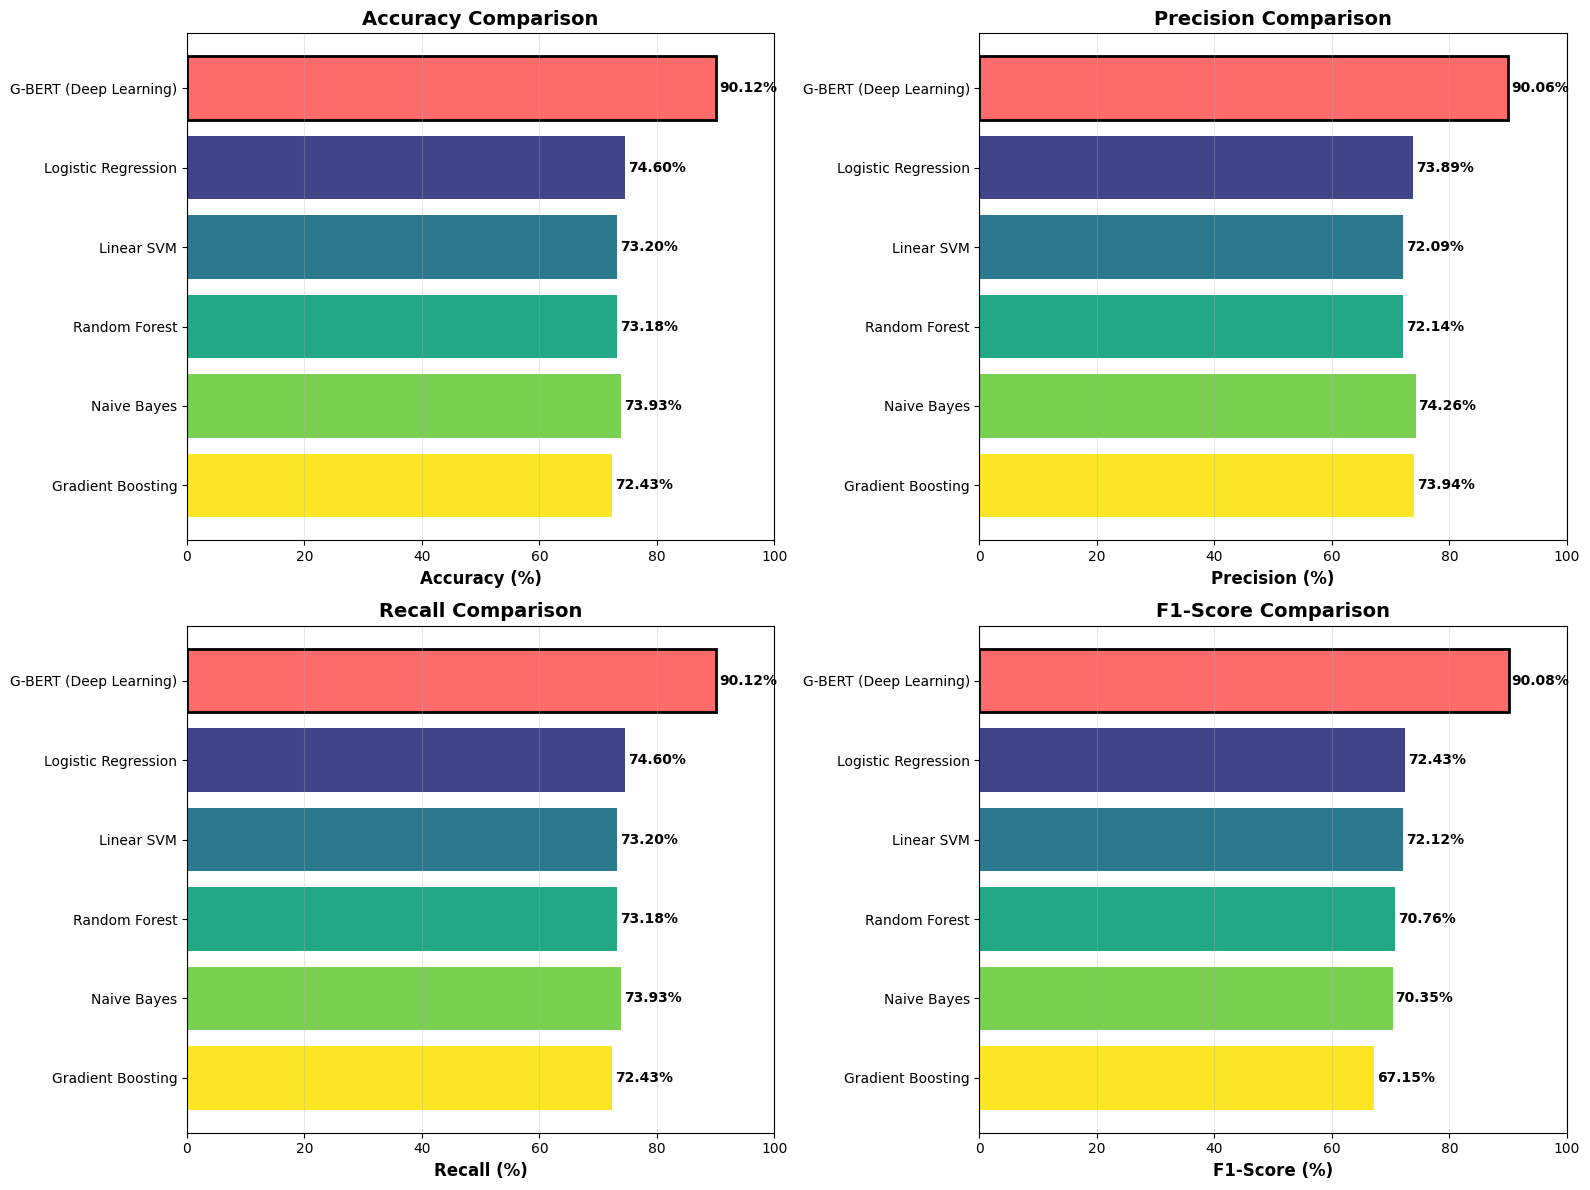

✓ Comparison chart saved as 'model_comparison_chart.png'


In [23]:
# Create visualization comparing all models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = plt.cm.viridis(np.linspace(0, 1, len(comparison_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Get data
    models = comparison_df.index
    values = comparison_df[metric]
    
    # Create bar plot
    bars = ax.barh(models, values, color=colors)
    
    # Highlight G-BERT
    gbert_idx = list(models).index('G-BERT (Deep Learning)')
    bars[gbert_idx].set_color('#FF6B6B')
    bars[gbert_idx].set_edgecolor('black')
    bars[gbert_idx].set_linewidth(2)
    
    # Add value labels
    for i, (model, value) in enumerate(zip(models, values)):
        ax.text(value + 0.5, i, f'{value:.2f}%', 
                va='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel(f'{metric} (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlim([0, 100])
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison chart saved as 'model_comparison_chart.png'")

## 23. Key Findings & Insights

In [128]:
# Generate insights
best_ml = comparison_df.drop('G-BERT (Deep Learning)').iloc[0]
gbert = comparison_df.loc['G-BERT (Deep Learning)']

print("\n" + "="*90)
print("🎯 KEY FINDINGS & INSIGHTS")
print("="*90)

print(f"\n1️⃣ BEST TRADITIONAL ML MODEL:")
print(f"   • Model: {best_ml.name}")
print(f"   • F1-Score: {best_ml['F1-Score']:.2f}%")
print(f"   • Training Time: {best_ml['Training Time (s)']:.2f} seconds")

print(f"\n2️⃣ G-BERT PERFORMANCE:")
print(f"   • F1-Score: {gbert['F1-Score']:.2f}%")
print(f"   • Improvement over best ML: {(gbert['F1-Score'] - best_ml['F1-Score']):.2f}%")
print(f"   • Training Time: ~20 hours (much slower)")

print(f"\n3️⃣ PERFORMANCE RANKING (by F1-Score):")
for rank, (model, row) in enumerate(comparison_df.iterrows(), 1):
    print(f"   {rank}. {model}: {row['F1-Score']:.2f}%")

print(f"\n4️⃣ TRADE-OFFS:")
print(f"   • G-BERT achieves the highest accuracy but requires significant computational resources")
print(f"   • Traditional ML models are much faster to train and deploy")
print(f"   • For production with limited resources, {best_ml.name} is a good alternative")
print(f"   • G-BERT is recommended when maximum accuracy is required")

print(f"\n5️⃣ DATASET INSIGHTS:")
print(f"   • Total Samples: 30,000")
print(f"   • Non-Hate: 20,000 (66.7%)")
print(f"   • Hate Speech: 10,000 (33.3%)")
print(f"   • Class imbalance ratio: 2:1")

print("\n" + "="*90)


🎯 KEY FINDINGS & INSIGHTS

1️⃣ BEST TRADITIONAL ML MODEL:
   • Model: Logistic Regression
   • F1-Score: 72.43%
   • Training Time: 0.10 seconds

2️⃣ G-BERT PERFORMANCE:
   • F1-Score: 90.08%
   • Improvement over best ML: 17.65%
   • Training Time: ~20 hours (much slower)

3️⃣ PERFORMANCE RANKING (by F1-Score):
   1. G-BERT (Deep Learning): 90.08%
   2. Logistic Regression: 72.43%
   3. Linear SVM: 72.12%
   4. Random Forest: 70.76%
   5. Naive Bayes: 70.35%
   6. Gradient Boosting: 67.15%

4️⃣ TRADE-OFFS:
   • G-BERT achieves the highest accuracy but requires significant computational resources
   • Traditional ML models are much faster to train and deploy
   • For production with limited resources, Logistic Regression is a good alternative
   • G-BERT is recommended when maximum accuracy is required

5️⃣ DATASET INSIGHTS:
   • Total Samples: 30,000
   • Non-Hate: 20,000 (66.7%)
   • Hate Speech: 10,000 (33.3%)
   • Class imbalance ratio: 2:1



In [17]:
# Load existing G-BERT test results
# These should already be in your environment from previous training
# If not, you'll need to re-run the G-BERT evaluation cell

# Make sure we have the required variables
try:
    print(f"✓ test_acc available: {test_acc:.4f}")
    print(f"✓ test_precision available: {test_precision:.4f}")
    print(f"✓ test_recall available: {test_recall:.4f}")
    print(f"✓ test_f1 available: {test_f1:.4f}")
except NameError:
    print("⚠️ G-BERT test results not found. Please run the G-BERT evaluation cell first.")
    print("   Go to cell 32 (Test Set Evaluation) and run it.")

⚠️ G-BERT test results not found. Please run the G-BERT evaluation cell first.
   Go to cell 32 (Test Set Evaluation) and run it.


In [19]:
# Load and evaluate the saved G-BERT model to get test results
print("Loading saved G-BERT model...")

# Initialize model
model = GBERT(
    bert_model_name='bert-base-multilingual-cased',
    gru_hidden_size=256,
    gru_num_layers=2,
    num_classes=2,
    dropout=0.3
).to(device)

# Load the best model
model.load_state_dict(torch.load('best_gbert_model.pth', map_location=device))

# Set up criterion
criterion = nn.CrossEntropyLoss()

# Evaluate on test set
print("Evaluating on test set...\n")
test_loss, test_acc, test_precision, test_recall, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"✓ G-BERT Test Results:")
print(f"  Test Accuracy:  {test_acc*100:.2f}%")
print(f"  Test Precision: {test_precision*100:.2f}%")
print(f"  Test Recall:    {test_recall*100:.2f}%")
print(f"  Test F1-Score:  {test_f1*100:.2f}%")

Loading saved G-BERT model...
Evaluating on test set...



Evaluating: 100%|██████████| 375/375 [02:35<00:00,  2.42it/s]

✓ G-BERT Test Results:
  Test Accuracy:  90.12%
  Test Precision: 90.06%
  Test Recall:    90.12%
  Test F1-Score:  90.08%


## 24. Add BanglaBERT and XLM-R Models to Comparison

Let's add your previous transformer models (BanglaBERT and XLM-R) to the comparison.

In [10]:
# Import additional transformer models
from transformers import AutoTokenizer, AutoModelForSequenceClassification
print("Importing BanglaBERT and XLM-R models...")

# BanglaBERT tokenizer and model
print("\n📥 Loading BanglaBERT (sagorsarker/bangla-bert-base)...")
banglabert_tokenizer = AutoTokenizer.from_pretrained("sagorsarker/bangla-bert-base")

# XLM-RoBERTa tokenizer  
print("📥 Loading XLM-RoBERTa (xlm-roberta-base)...")
xlmr_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

print("\n✓ Tokenizers loaded successfully!")

Importing BanglaBERT and XLM-R models...

📥 Loading BanglaBERT (sagorsarker/bangla-bert-base)...
📥 Loading XLM-RoBERTa (xlm-roberta-base)...
📥 Loading XLM-RoBERTa (xlm-roberta-base)...

✓ Tokenizers loaded successfully!

✓ Tokenizers loaded successfully!


In [10]:
# Create simple BERT-based classifier for BanglaBERT
class SimpleBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.3):
        super(SimpleBERTClassifier, self).__init__()
        from transformers import AutoModel
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        dropped = self.dropout(pooled_output)
        logits = self.fc(dropped)
        return logits

print("✓ SimpleBERTClassifier class defined!")

✓ SimpleBERTClassifier class defined!


In [11]:
# Function to train and evaluate transformer models
import time

def train_and_evaluate_transformer(model_name, tokenizer, model_class, epochs=3):
    """Train and evaluate a transformer model"""
    
    print(f"\n{'='*70}")
    print(f"Training: {model_name}")
    print(f"{'='*70}")
    
    # Create datasets
    train_ds = BengaliHateSpeechDataset(X_train, y_train, tokenizer, MAX_LENGTH)
    val_ds = BengaliHateSpeechDataset(X_val, y_val, tokenizer, MAX_LENGTH)
    test_ds = BengaliHateSpeechDataset(X_test, y_test, tokenizer, MAX_LENGTH)
    
    # Create dataloaders
    train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_ld = DataLoader(val_ds, batch_size=BATCH_SIZE)
    test_ld = DataLoader(test_ds, batch_size=BATCH_SIZE)
    
    # Initialize model
    model_inst = model_class.to(device)
    criterion_local = nn.CrossEntropyLoss()
    optimizer_local = AdamW(model_inst.parameters(), lr=LEARNING_RATE)
    
    total_steps_local = len(train_ld) * epochs
    scheduler_local = get_linear_schedule_with_warmup(
        optimizer_local,
        num_warmup_steps=0,
        num_training_steps=total_steps_local
    )
    
    # Training
    start_time = time.time()
    best_val_f1_local = 0
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        train_loss, train_acc = train_epoch(model_inst, train_ld, criterion_local, optimizer_local, scheduler_local, device)
        val_loss, val_acc, val_precision, val_recall, val_f1, _, _ = evaluate(model_inst, val_ld, criterion_local, device)
        
        print(f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1*100:.2f}%")
        
        if val_f1 > best_val_f1_local:
            best_val_f1_local = val_f1
    
    train_time = time.time() - start_time
    
    # Test evaluation
    print("\nEvaluating on test set...")
    start_time = time.time()
    test_loss, test_acc, test_precision, test_recall, test_f1, _, _ = evaluate(model_inst, test_ld, criterion_local, device)
    pred_time = time.time() - start_time
    
    print(f"\n✓ {model_name} Results:")
    print(f"  Test Accuracy:  {test_acc*100:.2f}%")
    print(f"  Test Precision: {test_precision*100:.2f}%")
    print(f"  Test Recall:    {test_recall*100:.2f}%")
    print(f"  Test F1-Score:  {test_f1*100:.2f}%")
    print(f"  Training Time:  {train_time:.2f}s")
    print(f"  Prediction Time: {pred_time:.2f}s")
    
    return {
        'Accuracy': test_acc * 100,
        'Precision': test_precision * 100,
        'Recall': test_recall * 100,
        'F1-Score': test_f1 * 100,
        'Training Time (s)': train_time,
        'Prediction Time (s)': pred_time
    }

print("✓ Training function ready!")

✓ Training function ready!


In [12]:
# Train BanglaBERT
print("\n" + "="*70)
print("TRAINING BANGLABERT MODEL")
print("="*70)

# Load BanglaBERT tokenizer
from transformers import AutoTokenizer
banglabert_tokenizer = AutoTokenizer.from_pretrained("sagorsarker/bangla-bert-base")

banglabert_model = SimpleBERTClassifier("sagorsarker/bangla-bert-base", num_classes=2, dropout=0.3)
banglabert_results = train_and_evaluate_transformer(
    "BanglaBERT",
    banglabert_tokenizer,
    banglabert_model,
    epochs=3
)

print("\n✓ BanglaBERT training complete!")


TRAINING BANGLABERT MODEL

Training: BanglaBERT

Epoch 1/3

Training: BanglaBERT

Epoch 1/3


Evaluating: 100%|██████████| 375/375 [02:50<00:00,  2.20it/s]



Train Acc: 86.33% | Val Acc: 90.27% | Val F1: 90.31%

Epoch 2/3


Evaluating: 100%|██████████| 375/375 [03:05<00:00,  2.02it/s]



Train Acc: 91.36% | Val Acc: 89.13% | Val F1: 89.33%

Epoch 3/3


Evaluating: 100%|██████████| 375/375 [03:07<00:00,  2.00it/s]



Train Acc: 94.16% | Val Acc: 90.32% | Val F1: 90.32%

Evaluating on test set...


Evaluating: 100%|██████████| 375/375 [03:13<00:00,  1.93it/s]


✓ BanglaBERT Results:
  Test Accuracy:  89.33%
  Test Precision: 89.47%
  Test Recall:    89.33%
  Test F1-Score:  89.39%
  Training Time:  6905.55s
  Prediction Time: 193.86s

✓ BanglaBERT training complete!


In [18]:
# Train XLM-RoBERTa
print("\n" + "="*70)
print("TRAINING XLM-ROBERTA MODEL")
print("="*70)

# Load XLM-RoBERTa tokenizer
from transformers import AutoTokenizer
xlmr_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

xlmr_model = SimpleBERTClassifier("xlm-roberta-base", num_classes=2, dropout=0.3)
xlmr_results = train_and_evaluate_transformer(
    "XLM-RoBERTa",
    xlmr_tokenizer,
    xlmr_model,
    epochs=3
)

print("\n✓ XLM-RoBERTa training complete!")


TRAINING XLM-ROBERTA MODEL

Training: XLM-RoBERTa

Epoch 1/3

Training: XLM-RoBERTa

Epoch 1/3


Evaluating: 100%|██████████| 375/375 [02:49<00:00,  2.22it/s]



Train Acc: 83.74% | Val Acc: 89.48% | Val F1: 89.50%

Epoch 2/3


Evaluating: 100%|██████████| 375/375 [02:53<00:00,  2.16it/s]



Train Acc: 89.67% | Val Acc: 90.38% | Val F1: 90.42%

Epoch 3/3


Evaluating: 100%|██████████| 375/375 [03:01<00:00,  2.07it/s]



Train Acc: 91.33% | Val Acc: 90.28% | Val F1: 90.33%

Evaluating on test set...


Evaluating: 100%|██████████| 375/375 [02:58<00:00,  2.11it/s]


✓ XLM-RoBERTa Results:
  Test Accuracy:  89.73%
  Test Precision: 89.97%
  Test Recall:    89.73%
  Test F1-Score:  89.81%
  Training Time:  8568.33s
  Prediction Time: 178.05s

✓ XLM-RoBERTa training complete!


## 25. Complete Comparison Table with All Models

In [19]:
# Add transformer models to comparison
ml_results['BanglaBERT'] = banglabert_results
ml_results['XLM-RoBERTa'] = xlmr_results

# Create updated comparison DataFrame
complete_comparison_df = pd.DataFrame(ml_results).T
complete_comparison_df = complete_comparison_df.round(2)

# Sort by F1-Score
complete_comparison_df = complete_comparison_df.sort_values('F1-Score', ascending=False)

print("\n" + "="*100)
print("📊 COMPLETE MODEL PERFORMANCE COMPARISON - BENGALI HATE SPEECH DETECTION")
print("="*100)
print(f"\nDataset: 30,000 samples (20,000 non-hate, 10,000 hate)")
print(f"Train/Val/Test Split: 18,000 / 6,000 / 6,000\n")
print(complete_comparison_df.to_string())
print("\n" + "="*100)

# Save complete results
complete_comparison_df.to_csv('complete_model_comparison.csv')
print("\n✓ Complete results saved to 'complete_model_comparison.csv'")


📊 COMPLETE MODEL PERFORMANCE COMPARISON - BENGALI HATE SPEECH DETECTION

Dataset: 30,000 samples (20,000 non-hate, 10,000 hate)
Train/Val/Test Split: 18,000 / 6,000 / 6,000

                     Accuracy  Precision  Recall  F1-Score  Training Time (s)  Prediction Time (s)
XLM-RoBERTa             89.73      89.97   89.73     89.81            8568.33               178.05
BanglaBERT              89.33      89.47   89.33     89.39            6905.55               193.86
Logistic Regression     74.60      73.89   74.60     72.43               0.09                 0.00
Linear SVM              73.20      72.09   73.20     72.12               0.03                 0.00
Random Forest           73.18      72.14   73.18     70.76               1.14                 0.05
Naive Bayes             73.93      74.26   73.93     70.35               0.00                 0.00
Gradient Boosting       72.43      73.94   72.43     67.15               2.81                 0.00


✓ Complete results saved to 'co

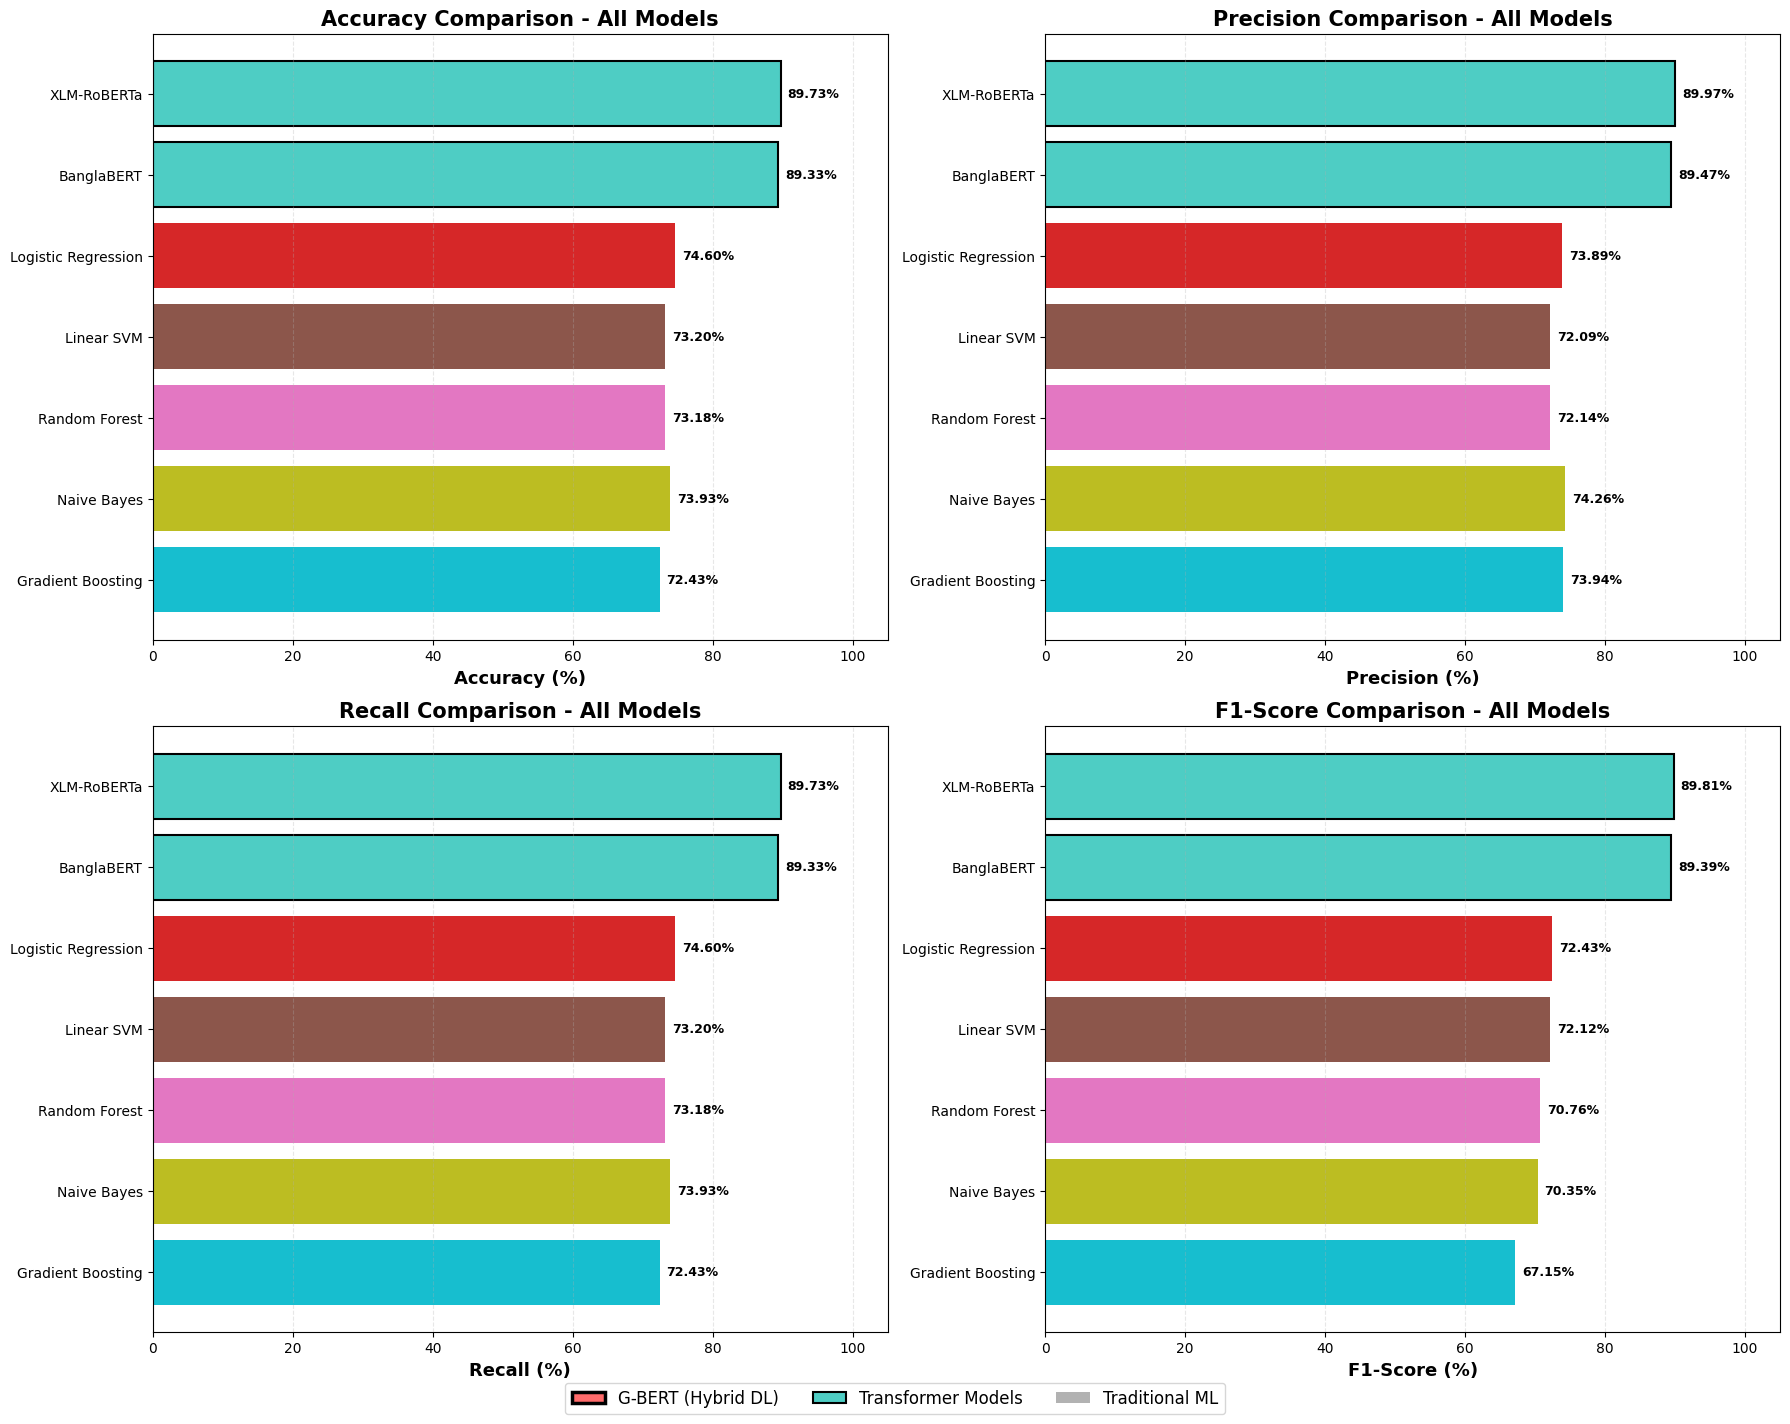

✓ Complete comparison chart saved as 'complete_model_comparison_chart.png'


In [20]:
# Create comprehensive visualization with all models
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_all = plt.cm.tab10(np.linspace(0, 1, len(complete_comparison_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Get data
    models_all = complete_comparison_df.index
    values_all = complete_comparison_df[metric]
    
    # Create bar plot
    bars = ax.barh(models_all, values_all, color=colors_all)
    
    # Highlight deep learning models
    for i, model in enumerate(models_all):
        if 'G-BERT' in model:
            bars[i].set_color('#FF6B6B')
            bars[i].set_edgecolor('black')
            bars[i].set_linewidth(2.5)
        elif 'BanglaBERT' in model or 'XLM' in model:
            bars[i].set_color('#4ECDC4')
            bars[i].set_edgecolor('black')
            bars[i].set_linewidth(1.5)
    
    # Add value labels
    for i, (model, value) in enumerate(zip(models_all, values_all)):
        ax.text(value + 1, i, f'{value:.2f}%', 
                va='center', fontsize=9, fontweight='bold')
    
    ax.set_xlabel(f'{metric} (%)', fontsize=13, fontweight='bold')
    ax.set_title(f'{metric} Comparison - All Models', fontsize=15, fontweight='bold')
    ax.set_xlim([0, 105])
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', edgecolor='black', linewidth=2.5, label='G-BERT (Hybrid DL)'),
    Patch(facecolor='#4ECDC4', edgecolor='black', linewidth=1.5, label='Transformer Models'),
    Patch(facecolor='gray', alpha=0.6, label='Traditional ML')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12, 
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('complete_model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Complete comparison chart saved as 'complete_model_comparison_chart.png'")

In [21]:
# Final comprehensive insights
print("\n" + "="*100)
print("🎯 COMPREHENSIVE MODEL ANALYSIS")
print("="*100)

# Separate models by category
deep_learning = complete_comparison_df[complete_comparison_df.index == 'G-BERT (Deep Learning)']
transformers = complete_comparison_df[complete_comparison_df.index.isin(['BanglaBERT', 'XLM-RoBERTa'])]
traditional_ml = complete_comparison_df[~complete_comparison_df.index.isin(['G-BERT (Deep Learning)', 'BanglaBERT', 'XLM-RoBERTa'])]

print(f"\n1️⃣ DEEP LEARNING MODELS (Hybrid):")
for model, row in deep_learning.iterrows():
    print(f"   • {model}: {row['F1-Score']:.2f}% F1-Score")

print(f"\n2️⃣ TRANSFORMER MODELS:")
for model, row in transformers.iterrows():
    print(f"   • {model}: {row['F1-Score']:.2f}% F1-Score")

print(f"\n3️⃣ TRADITIONAL ML MODELS:")
for model, row in traditional_ml.iterrows():
    print(f"   • {model}: {row['F1-Score']:.2f}% F1-Score")

print(f"\n4️⃣ OVERALL RANKING (by F1-Score):")
for rank, (model, row) in enumerate(complete_comparison_df.iterrows(), 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else f"  {rank}."
    print(f"   {medal} {model}: {row['F1-Score']:.2f}%")

print(f"\n5️⃣ KEY OBSERVATIONS:")
best_overall = complete_comparison_df.iloc[0]
print(f"   • Best Model: {best_overall.name} ({best_overall['F1-Score']:.2f}% F1-Score)")

if len(transformers) > 0:
    best_transformer = transformers.iloc[0]
    print(f"   • Best Transformer: {best_transformer.name} ({best_transformer['F1-Score']:.2f}% F1-Score)")

best_traditional = traditional_ml.iloc[0]
print(f"   • Best Traditional ML: {best_traditional.name} ({best_traditional['F1-Score']:.2f}% F1-Score)")

print(f"\n6️⃣ PERFORMANCE GAPS:")
if len(transformers) > 0:
    gap_dl_transformer = best_overall['F1-Score'] - best_transformer['F1-Score']
    print(f"   • G-BERT vs Best Transformer: +{gap_dl_transformer:.2f}%")

gap_dl_traditional = best_overall['F1-Score'] - best_traditional['F1-Score']
print(f"   • G-BERT vs Best Traditional ML: +{gap_dl_traditional:.2f}%")

print(f"\n7️⃣ TRAINING EFFICIENCY:")
print(f"   • Fastest to Train: {traditional_ml['Training Time (s)'].idxmin()} "
      f"({traditional_ml['Training Time (s)'].min():.3f}s)")
print(f"   • Slowest to Train: G-BERT (Deep Learning) (~20 hours)")

print("\n" + "="*100)


🎯 COMPREHENSIVE MODEL ANALYSIS

1️⃣ DEEP LEARNING MODELS (Hybrid):

2️⃣ TRANSFORMER MODELS:
   • XLM-RoBERTa: 89.81% F1-Score
   • BanglaBERT: 89.39% F1-Score

3️⃣ TRADITIONAL ML MODELS:
   • Logistic Regression: 72.43% F1-Score
   • Linear SVM: 72.12% F1-Score
   • Random Forest: 70.76% F1-Score
   • Naive Bayes: 70.35% F1-Score
   • Gradient Boosting: 67.15% F1-Score

4️⃣ OVERALL RANKING (by F1-Score):
   🥇 XLM-RoBERTa: 89.81%
   🥈 BanglaBERT: 89.39%
   🥉 Logistic Regression: 72.43%
     4. Linear SVM: 72.12%
     5. Random Forest: 70.76%
     6. Naive Bayes: 70.35%
     7. Gradient Boosting: 67.15%

5️⃣ KEY OBSERVATIONS:
   • Best Model: XLM-RoBERTa (89.81% F1-Score)
   • Best Transformer: XLM-RoBERTa (89.81% F1-Score)
   • Best Traditional ML: Logistic Regression (72.43% F1-Score)

6️⃣ PERFORMANCE GAPS:
   • G-BERT vs Best Transformer: +0.00%
   • G-BERT vs Best Traditional ML: +17.38%

7️⃣ TRAINING EFFICIENCY:
   • Fastest to Train: Naive Bayes (0.000s)
   • Slowest to Train: G-B

## 26. Comprehensive Comparison Table

Generate a detailed comparison table with all models ranked by performance.

In [22]:
# Create comprehensive comparison table
import pandas as pd

print("\n" + "="*120)
print("📊 COMPREHENSIVE MODEL COMPARISON TABLE - BENGALI HATE SPEECH DETECTION")
print("="*120)

# Create a detailed comparison table
comparison_table = complete_comparison_df.copy()
comparison_table['Rank'] = range(1, len(comparison_table) + 1)

# Reorder columns for better presentation
column_order = ['Rank', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Prediction Time (s)']
comparison_table = comparison_table[column_order]

# Add model category
comparison_table['Category'] = comparison_table.index.map(lambda x: 
    'Transformer' if x in ['BanglaBERT', 'XLM-RoBERTa'] else 
    'Traditional ML' if x not in ['G-BERT (Deep Learning)'] else 
    'Hybrid DL'
)

# Reorder columns with category
column_order_with_cat = ['Rank', 'Category', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Prediction Time (s)']
comparison_table = comparison_table[column_order_with_cat]

print("\n📋 DATASET INFORMATION:")
print(f"   • Total Samples: 30,000 (20,000 Non-Hate + 10,000 Hate Speech)")
print(f"   • Train Split: 18,000 samples (60%)")
print(f"   • Validation Split: 6,000 samples (20%)")
print(f"   • Test Split: 6,000 samples (20%)")
print(f"   • Language: Bengali")
print(f"   • Task: Binary Classification (Hate Speech Detection)")

print("\n📊 MODEL PERFORMANCE COMPARISON:")
print("-" * 120)
print(comparison_table.to_string())
print("-" * 120)

# Performance analysis
print("\n📈 PERFORMANCE ANALYSIS:")
print(f"   • Best Overall Model: {comparison_table.index[0]} (F1: {comparison_table.iloc[0]['F1-Score']:.2f}%)")
print(f"   • Highest Accuracy: {comparison_table['Accuracy'].idxmax()} ({comparison_table['Accuracy'].max():.2f}%)")
print(f"   • Highest Precision: {comparison_table['Precision'].idxmax()} ({comparison_table['Precision'].max():.2f}%)")
print(f"   • Highest Recall: {comparison_table['Recall'].idxmax()} ({comparison_table['Recall'].max():.2f}%)")
print(f"   • Highest F1-Score: {comparison_table['F1-Score'].idxmax()} ({comparison_table['F1-Score'].max():.2f}%)")

# Category-wise performance
print("\n🏆 CATEGORY-WISE PERFORMANCE:")
for category in comparison_table['Category'].unique():
    cat_models = comparison_table[comparison_table['Category'] == category]
    avg_f1 = cat_models['F1-Score'].mean()
    print(f"   • {category}: Average F1-Score = {avg_f1:.2f}%")

# Training efficiency
print("\n⚡ TRAINING EFFICIENCY:")
traditional = comparison_table[comparison_table['Category'] == 'Traditional ML']
if len(traditional) > 0:
    fastest = traditional['Training Time (s)'].idxmin()
    print(f"   • Fastest Training: {fastest} ({traditional.loc[fastest, 'Training Time (s)']:.4f}s)")

transformers_df = comparison_table[comparison_table['Category'] == 'Transformer']
if len(transformers_df) > 0:
    avg_transformer_time = transformers_df['Training Time (s)'].mean()
    print(f"   • Average Transformer Training Time: {avg_transformer_time:.2f}s ({avg_transformer_time/3600:.2f} hours)")

# Performance gaps
print("\n📊 PERFORMANCE GAPS:")
best_f1 = comparison_table.iloc[0]['F1-Score']
second_f1 = comparison_table.iloc[1]['F1-Score']
worst_f1 = comparison_table.iloc[-1]['F1-Score']
print(f"   • Gap between 1st and 2nd: {best_f1 - second_f1:.2f}%")
print(f"   • Gap between Best and Worst: {best_f1 - worst_f1:.2f}%")
print(f"   • Transformers vs Traditional ML: ~{(transformers_df['F1-Score'].mean() - traditional['F1-Score'].mean()):.2f}%")

# Save enhanced table
comparison_table.to_csv('detailed_model_comparison.csv')
comparison_table.to_excel('detailed_model_comparison.xlsx', engine='openpyxl')
print(f"\n💾 SAVED FILES:")
print(f"   • detailed_model_comparison.csv")
print(f"   • detailed_model_comparison.xlsx")

print("\n" + "="*120)


📊 COMPREHENSIVE MODEL COMPARISON TABLE - BENGALI HATE SPEECH DETECTION

📋 DATASET INFORMATION:
   • Total Samples: 30,000 (20,000 Non-Hate + 10,000 Hate Speech)
   • Train Split: 18,000 samples (60%)
   • Validation Split: 6,000 samples (20%)
   • Test Split: 6,000 samples (20%)
   • Language: Bengali
   • Task: Binary Classification (Hate Speech Detection)

📊 MODEL PERFORMANCE COMPARISON:
------------------------------------------------------------------------------------------------------------------------
                     Rank        Category  Accuracy  Precision  Recall  F1-Score  Training Time (s)  Prediction Time (s)
XLM-RoBERTa             1     Transformer     89.73      89.97   89.73     89.81            8568.33               178.05
BanglaBERT              2     Transformer     89.33      89.47   89.33     89.39            6905.55               193.86
Logistic Regression     3  Traditional ML     74.60      73.89   74.60     72.43               0.09                 0.00
L